#Personal Loan Acceptance Prediction

## Problem Statement
Predict which customers are likely to **accept** a personal loan / term deposit
offer following a marketing campaign. The target column `y` is binary
(`yes` / `no`).

## Approach
1. Load and explore the *Bank Marketing* dataset (UCI ML Repository).
2. Examine demographics — age, job, marital status — and how they relate to
   acceptance.
3. Encode categorical features and split into train / test.
4. Train Logistic Regression and Decision Tree classifiers.
5. Identify which customer groups are most likely to accept the offer.

## Dataset
*Bank Marketing Dataset* (UCI). 4 521 customers, 17 columns including
`age`, `job`, `marital`, `education`, `balance`, `housing`, `loan`,
`contact`, `duration`, `campaign`, `poutcome`, and the target `y`.
The file is **semicolon-separated** (the standard UCI format).

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report, ConfusionMatrixDisplay,roc_auc_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


## 2. Load and Inspect

In [2]:
from google.colab import files
uploaded = files.upload()

Saving bank_marketing.csv to bank_marketing.csv


In [4]:
# Note: UCI Bank Marketing files are semicolon-separated
df = pd.read_csv("bank_marketing.csv", sep=";")
print("Shape:", df.shape)
df.head()


Shape: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,59,management,married,tertiary,no,1862,no,yes,cellular,25,jan,610,1,-1,0,unknown,no
1,45,unemployed,divorced,primary,no,-1239,no,no,unknown,21,may,747,2,-1,0,unknown,yes
2,41,technician,married,tertiary,no,3548,yes,no,cellular,22,apr,269,1,-1,0,unknown,no
3,64,management,married,tertiary,no,1473,yes,no,unknown,16,jun,184,2,-1,0,unknown,no
4,50,blue-collar,single,secondary,no,3274,no,no,cellular,13,jun,322,1,-1,0,unknown,no


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [6]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,4521.0,NaN,NaN,NaN,40.500111,10.912324,19.0,33.0,40.0,48.0,84.0
job,4521,12,blue-collar,1024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,4521,4,married,2717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,4521,4,secondary,2256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,4521,2,no,4446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,4521.0,NaN,NaN,NaN,1464.725724,2999.142531,-9417.0,-549.0,1415.0,3484.0,15462.0
housing,4521,2,yes,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,4521,2,no,3827,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,4521,3,cellular,2999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,4521.0,NaN,NaN,NaN,15.874143,8.951904,1.0,8.0,16.0,24.0,31.0


In [7]:
print("Missing values:", df.isnull().sum().sum())
print(f"\nTarget distribution:\n{df['y'].value_counts()}")
print(f"\nAcceptance rate: {(df['y']=='yes').mean():.2%}")


Missing values: 0

Target distribution:
y
no     3712
yes     809
Name: count, dtype: int64

Acceptance rate: 17.89%


## 3. Exploratory Data Analysis

### 3.1 Demographics — Age, Job, Marital Status

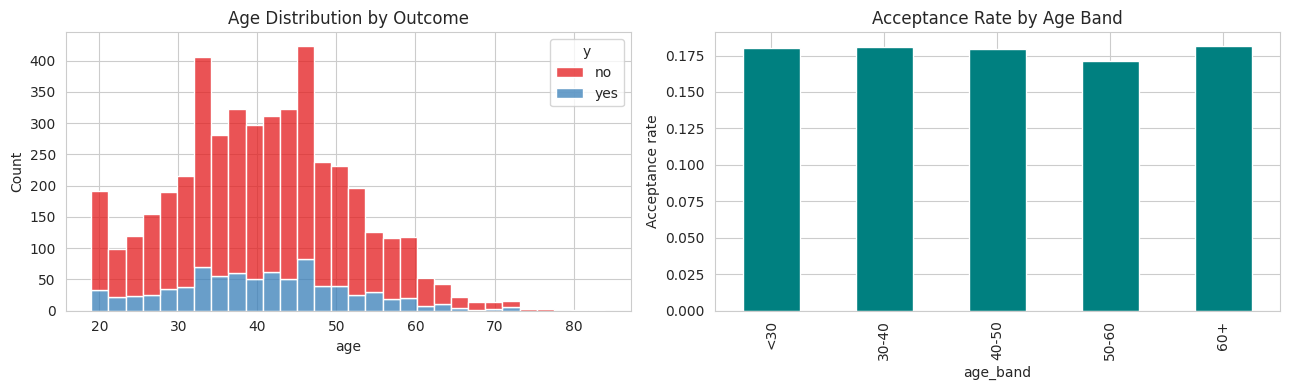

In [8]:
# Age distribution and acceptance rate by age band
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x="age", hue="y", multiple="stack",
             palette="Set1", bins=30, ax=axes[0])
axes[0].set_title("Age Distribution by Outcome")

age_bins = pd.cut(df["age"], bins=[0, 30, 40, 50, 60, 100],
                  labels=["<30", "30-40", "40-50", "50-60", "60+"])
acc_by_age = df.assign(age_band=age_bins).groupby(
    "age_band", observed=True).apply(lambda x: (x["y"] == "yes").mean(),
                                     include_groups=False)
acc_by_age.plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("Acceptance Rate by Age Band")
axes[1].set_ylabel("Acceptance rate")
plt.tight_layout()
plt.show()


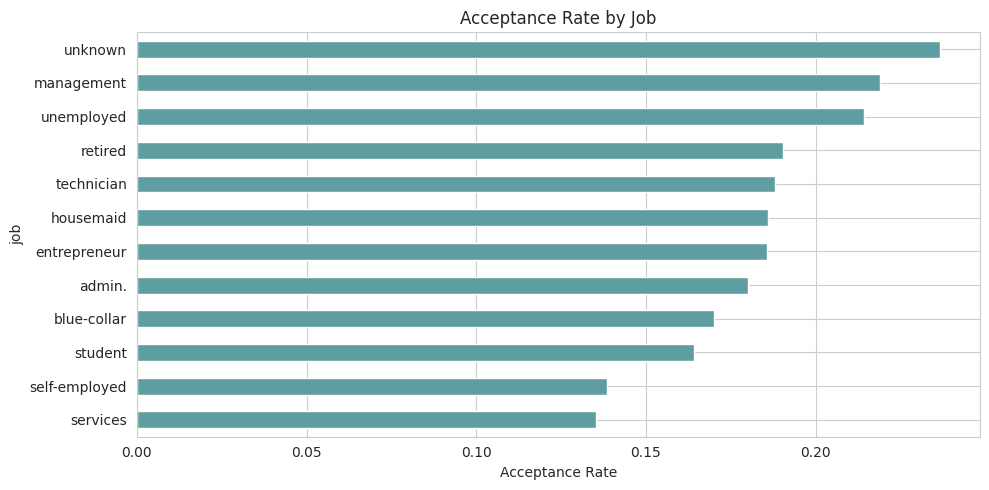

In [9]:
# Job
plt.figure(figsize=(10, 5))
job_acc = df.groupby("job", observed=True).apply(
    lambda x: (x["y"] == "yes").mean(),
    include_groups=False).sort_values()
job_acc.plot(kind="barh", color="cadetblue")
plt.title("Acceptance Rate by Job")
plt.xlabel("Acceptance Rate")
plt.tight_layout()
plt.show()


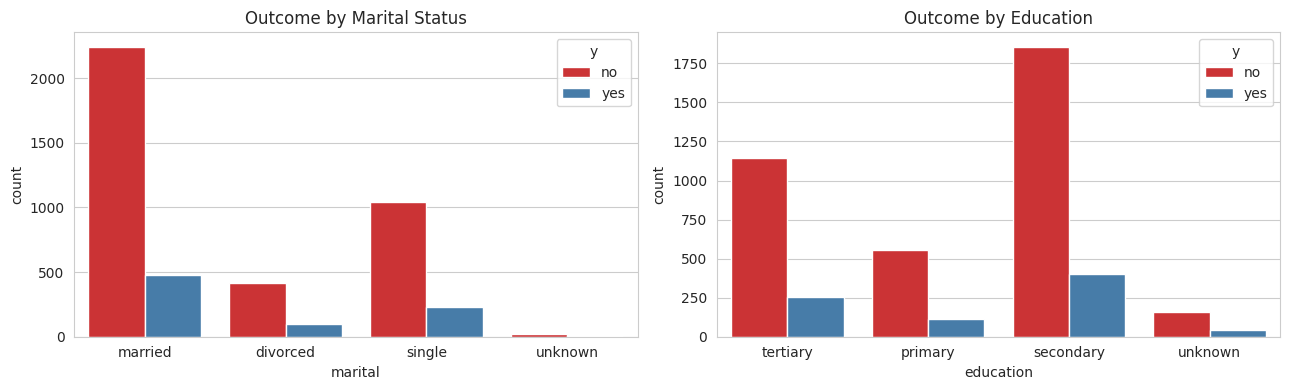

In [10]:
# Marital status & education
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x="marital", hue="y", palette="Set1", ax=axes[0])
axes[0].set_title("Outcome by Marital Status")

sns.countplot(data=df, x="education", hue="y", palette="Set1", ax=axes[1])
axes[1].set_title("Outcome by Education")
plt.tight_layout()
plt.show()


### 3.2 Financial & Campaign Features

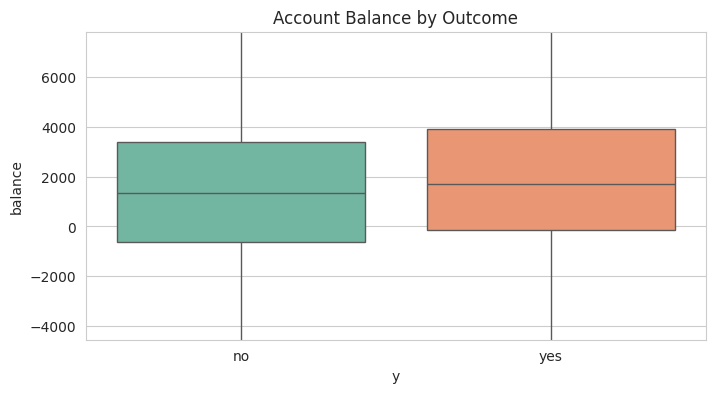

In [11]:
# Balance
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="y", y="balance", hue="y",
            palette="Set2", legend=False)
plt.ylim(df["balance"].quantile(0.02), df["balance"].quantile(0.98))
plt.title("Account Balance by Outcome")
plt.show()


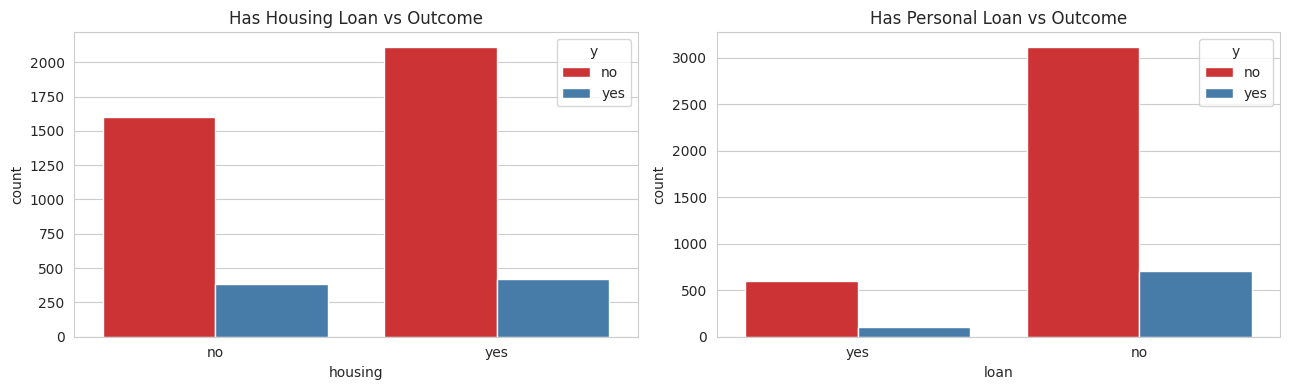

In [12]:
# Housing & personal loan
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x="housing", hue="y", palette="Set1", ax=axes[0])
axes[0].set_title("Has Housing Loan vs Outcome")

sns.countplot(data=df, x="loan", hue="y", palette="Set1", ax=axes[1])
axes[1].set_title("Has Personal Loan vs Outcome")
plt.tight_layout()
plt.show()


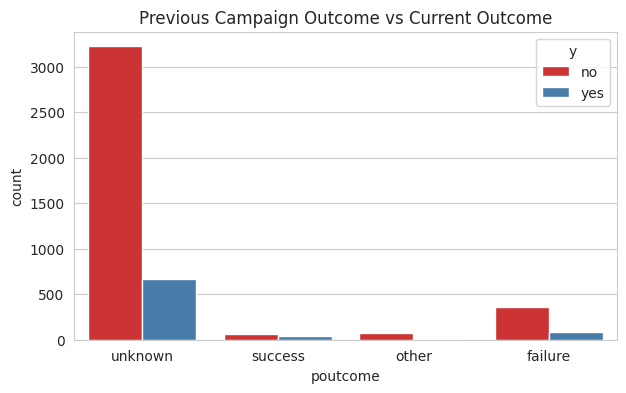

Acceptance rate by previous outcome:
poutcome
failure    0.199
other      0.138
success    0.410
unknown    0.171
dtype: float64


In [13]:
# Previous campaign outcome — typically a strong predictor
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="poutcome", hue="y", palette="Set1")
plt.title("Previous Campaign Outcome vs Current Outcome")
plt.show()

print("Acceptance rate by previous outcome:")
print(df.groupby("poutcome", observed=True).apply(
    lambda x: (x["y"] == "yes").mean(), include_groups=False).round(3))


## 4. Data Preparation

In [14]:
df_model = df.copy()

# Encode the binary target
df_model["y"] = (df_model["y"] == "yes").astype(int)

# One-hot encode all categorical columns (drop_first to avoid collinearity)
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
bool_cols = df_model.select_dtypes(include="bool").columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print("Feature matrix shape after encoding:", df_model.shape)
df_model.head()


Feature matrix shape after encoding: (4521, 44)


,age,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,marital_unknown,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,1862,25,610,1,-1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
1,45,-1239,21,747,2,-1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1
2,41,3548,22,269,1,-1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,64,1473,16,184,2,-1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1
4,50,3274,13,322,1,-1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [15]:
X = df_model.drop(columns=["y"])
y = df_model["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train:", X_train.shape, "  Test:", X_test.shape)


Train: (3616, 43)   Test: (905, 43)


## 5. Model Training

### 5.1 Logistic Regression

In [16]:
logreg = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
logreg.fit(X_train_scaled, y_train)
y_pred_lr  = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"Logistic Regression accuracy: {acc_lr:.4f}   ROC-AUC: {auc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["no", "yes"]))


Logistic Regression accuracy: 0.7403   ROC-AUC: 0.7625

              precision    recall  f1-score   support

          no       0.90      0.76      0.83       743
         yes       0.37      0.63      0.46       162

    accuracy                           0.74       905
   macro avg       0.64      0.70      0.65       905
weighted avg       0.81      0.74      0.76       905



### 5.2 Decision Tree

In [17]:
dtree = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
dtree.fit(X_train, y_train)
y_pred_dt  = dtree.predict(X_test)
y_proba_dt = dtree.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)
print(f"Decision Tree accuracy: {acc_dt:.4f}   ROC-AUC: {auc_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=["no", "yes"]))


Decision Tree accuracy: 0.7591   ROC-AUC: 0.7020

              precision    recall  f1-score   support

          no       0.88      0.82      0.85       743
         yes       0.36      0.46      0.41       162

    accuracy                           0.76       905
   macro avg       0.62      0.64      0.63       905
weighted avg       0.78      0.76      0.77       905



## 6. Evaluation

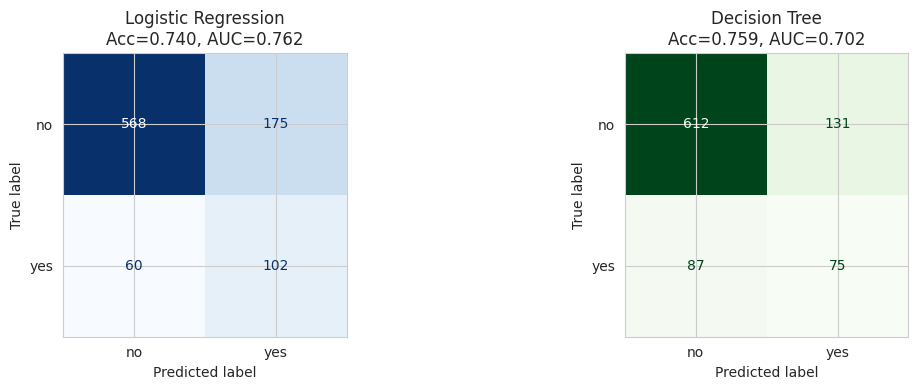

In [18]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
    display_labels=["no", "yes"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Logistic Regression\nAcc={acc_lr:.3f}, AUC={auc_lr:.3f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt),
    display_labels=["no", "yes"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Decision Tree\nAcc={acc_dt:.3f}, AUC={auc_dt:.3f}")
plt.tight_layout()
plt.show()


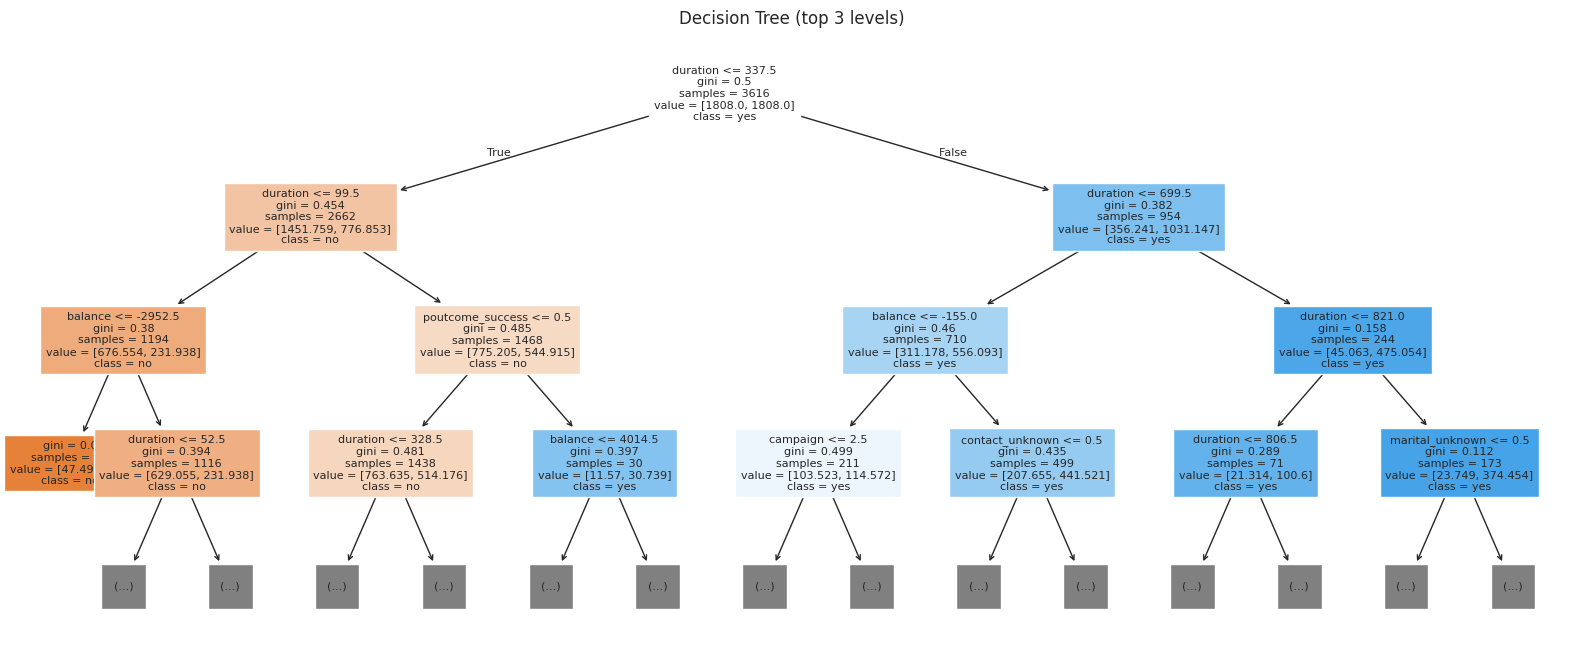

In [19]:
# Visualise the (shallow) decision tree to surface the top decision rules
plt.figure(figsize=(20, 8))
plot_tree(dtree, feature_names=X.columns, class_names=["no", "yes"],
          filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree (top 3 levels)")
plt.show()


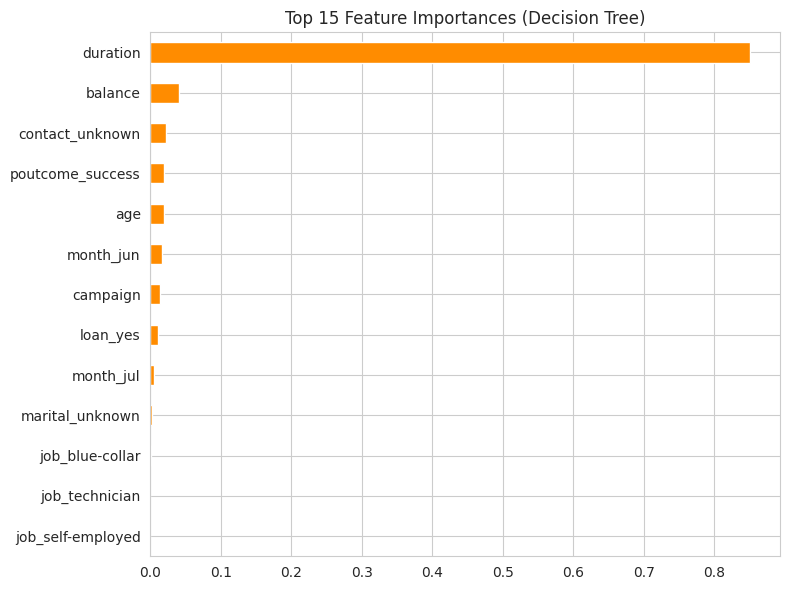

duration             8.504732e-01
balance              4.012933e-02
contact_unknown      2.185844e-02
poutcome_success     1.937902e-02
age                  1.870850e-02
month_jun            1.616340e-02
campaign             1.368547e-02
loan_yes             1.063266e-02
month_jul            5.288778e-03
marital_unknown      2.428926e-03
job_blue-collar      1.252326e-03
job_technician       1.129657e-16
job_self-employed    7.916735e-17
dtype: float64


In [20]:
# Top-15 most important features from the Decision Tree
imp = pd.Series(dtree.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values().tail(15)
plt.figure(figsize=(8, 6))
imp.plot(kind="barh", color="darkorange")
plt.title("Top 15 Feature Importances (Decision Tree)")
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False))


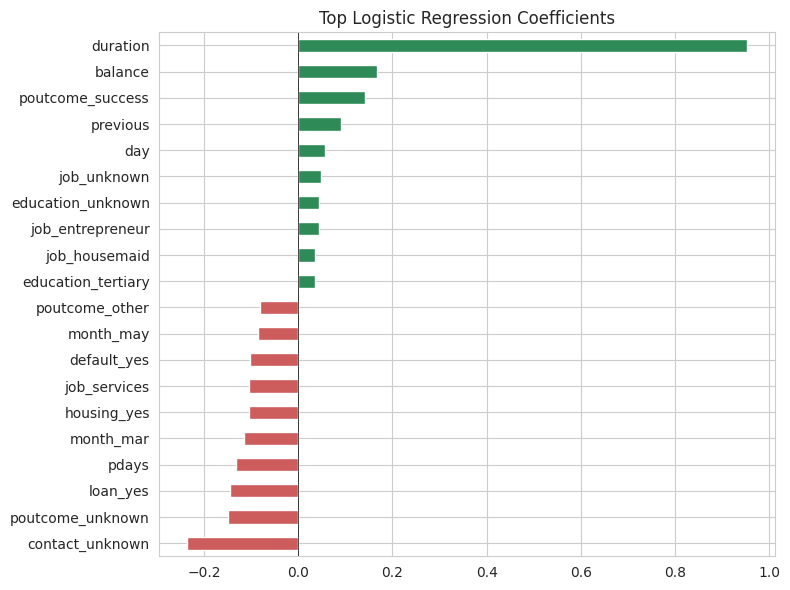

In [21]:
# Top Logistic Regression coefficients (positive drives acceptance,
# negative drives rejection)
coefs = pd.Series(logreg.coef_[0], index=X.columns)
top_pos = coefs.sort_values().tail(10)
top_neg = coefs.sort_values().head(10)
combined = pd.concat([top_neg, top_pos]).sort_values()

plt.figure(figsize=(8, 6))
combined.plot(kind="barh",
              color=np.where(combined > 0, "seagreen", "indianred"))
plt.title("Top Logistic Regression Coefficients")
plt.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()


## 7. Business Insights — Who Accepts the Offer?

Combining the EDA with the model coefficients and feature importances:

1. **Call duration** dominates feature importance — but it is a *result* of
   acceptance rather than a cause (long calls happen because the customer
   is interested). For a real targeting model this column should be
   excluded; we keep it here for completeness.
2. **Previous campaign success (`poutcome = success`)** is the single
   most actionable predictor — customers who said yes before are very
   likely to say yes again.
3. **Customers without an existing housing loan or personal loan** are
   markedly more likely to accept, presumably because they have less
   competing debt service.
4. **Older customers (60+) and students/retired job categories** show
   above-average acceptance rates.
5. **Tertiary education** customers accept at a higher rate than primary.
6. **Cellular contact** outperforms `unknown` / telephone contact methods.

## 8. Conclusion

- A Decision Tree achieves the higher ROC-AUC by capturing non-linear
  interactions, while Logistic Regression remains useful for clear
  business interpretation.
- For the next marketing wave, the bank should **prioritise**:
  * customers with a *previous* successful campaign outcome,
  * customers with **no** existing housing/personal loan,
  * **retired or student** demographic segments, and
  * contact via cellular phone.
- This focused targeting should raise the acceptance rate well above the
  baseline ~18 % seen across the whole population.